In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [ ]:
train_dir = "/content/drive/MyDrive/training"
val_dir   = "/content/drive/MyDrive/validation"

train_csv = "/content/drive/MyDrive/ISIC-2017_Training_Part3_GroundTruth.csv"
val_csv   = "/content/drive/MyDrive/ISIC-2017_Validation_Part3_GroundTruth.csv"

output_dir = "/content/drive/MyDrive/isic_efficientnet_output"
os.makedirs(output_dir, exist_ok=True)

In [ ]:
print("Train folder exists:", os.path.exists(train_dir))
print("Val folder exists:", os.path.exists(val_dir))
print("Train CSV exists:", os.path.exists(train_csv))
print("Val CSV exists:", os.path.exists(val_csv))

Train folder exists: True
Val folder exists: True
Train CSV exists: True
Val CSV exists: True


In [ ]:
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)

print("Training CSV columns:", train_df.columns.tolist())
print("Validation CSV columns:", val_df.columns.tolist())

print(train_df.head())
print(val_df.head())

Training CSV columns: ['image_id', 'melanoma', 'seborrheic_keratosis']
Validation CSV columns: ['image_id', 'melanoma', 'seborrheic_keratosis']
       image_id  melanoma  seborrheic_keratosis
0  ISIC_0000000       0.0                   0.0
1  ISIC_0000001       0.0                   0.0
2  ISIC_0000002       1.0                   0.0
3  ISIC_0000003       0.0                   0.0
4  ISIC_0000004       1.0                   0.0
       image_id  melanoma  seborrheic_keratosis
0  ISIC_0001769         0                     0
1  ISIC_0001852         0                     0
2  ISIC_0001871         0                     0
3  ISIC_0003462         0                     0
4  ISIC_0003539         0                     0


In [ ]:
train_df["filename"] = train_df["image_id"].astype(str) + ".jpg"
val_df["filename"] = val_df["image_id"].astype(str) + ".jpg"

train_df["filepath"] = train_df["filename"].apply(lambda x: os.path.join(train_dir, x))
val_df["filepath"] = val_df["filename"].apply(lambda x: os.path.join(val_dir, x))

train_df["label"] = train_df["melanoma"].astype(int)
val_df["label"] = val_df["melanoma"].astype(int)

train_df = train_df[train_df["filepath"].apply(os.path.exists)].reset_index(drop=True)
val_df = val_df[val_df["filepath"].apply(os.path.exists)].reset_index(drop=True)

print("Training images found:", len(train_df))
print("Validation images found:", len(val_df))

print("\nTraining label distribution:")
print(train_df["label"].value_counts())

print("\nValidation label distribution:")
print(val_df["label"].value_counts())

Training images found: 2000
Validation images found: 150

Training label distribution:
label
0    1626
1     374
Name: count, dtype: int64

Validation label distribution:
label
0    120
1     30
Name: count, dtype: int64


In [ ]:
class_weights_array = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.6150061500615006), 1: np.float64(2.6737967914438503)}


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 15
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = preprocess_input(img)
    return img, label

def augment_image(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    return img, label

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["filepath"].values, train_df["label"].values)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["filepath"].values, val_df["label"].values)
)

train_ds = (
    train_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .map(augment_image, num_parallel_calls=AUTOTUNE)
    .shuffle(buffer_size=len(train_df), reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

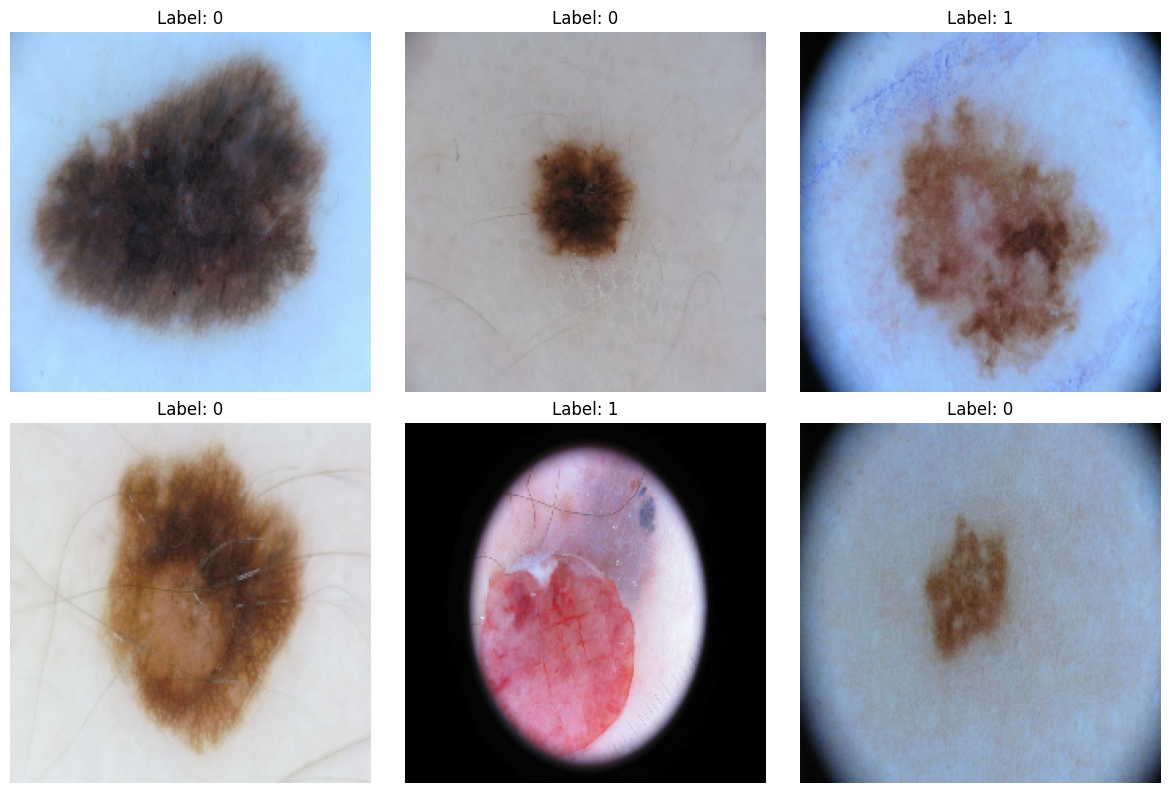

In [ ]:
def load_image_for_display(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.uint8)
    return img

plt.figure(figsize=(12, 8))
for i in range(6):
    img = load_image_for_display(train_df["filepath"].iloc[i])
    label = train_df["label"].iloc[i]
    ax = plt.subplot(2, 3, i + 1)
    plt.imshow(img.numpy())
    plt.title(f"Label: {label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(output_dir, "best_efficientnet.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 958ms/step - accuracy: 0.3941 - auc: 0.5435 - loss: 0.7361
Epoch 1: val_loss improved from None to 0.69384, saving model to /content/drive/MyDrive/isic_efficientnet_output/best_efficientnet.keras

Epoch 1: finished saving model to /content/drive/MyDrive/isic_efficientnet_output/best_efficientnet.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 755s 1s/step - accuracy: 0.4430 - auc: 0.5372 - loss: 0.7197 - val_accuracy: 0.5400 - val_auc: 0.4835 - val_loss: 0.6938 - learning_rate: 1.0000e-04
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 965ms/step - accuracy: 0.5448 - auc: 0.5843 - loss: 0.6919
Epoch 2: val_loss improved from 0.69384 to 0.65327, saving model to /content/drive/MyDrive/isic_efficientnet_output/best_efficientnet.keras

Epoch 2: finished saving model to /content/drive/MyDrive/isic_efficientnet_output/best_efficientnet.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 323s 1s/step - accuracy: 0.5410 - auc: 0.5744 - loss: 0.6982 - val_accuracy: 0.5933 - val_auc: 0.5

In [ ]:
final_model_path = os.path.join(output_dir, "final_efficientnet.keras")
model.save(final_model_path)
print("Model saved to:", final_model_path)

Model saved to: /content/drive/MyDrive/isic_efficientnet_output/final_efficientnet.keras


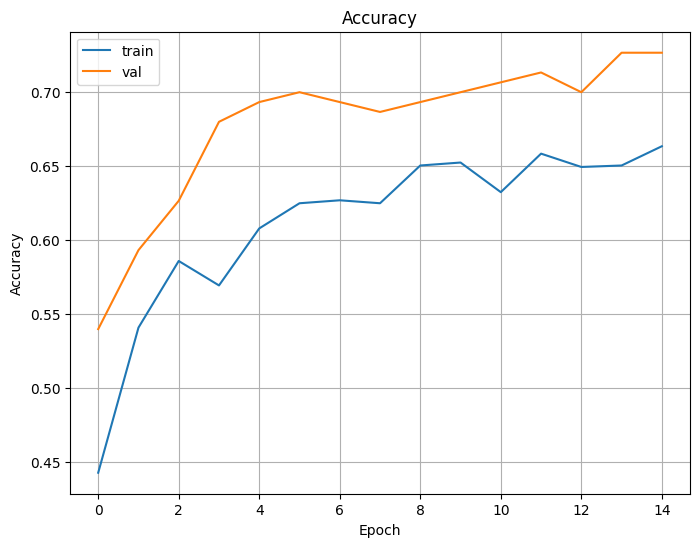

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, "accuracy.png"), dpi=300, bbox_inches="tight")
plt.show()

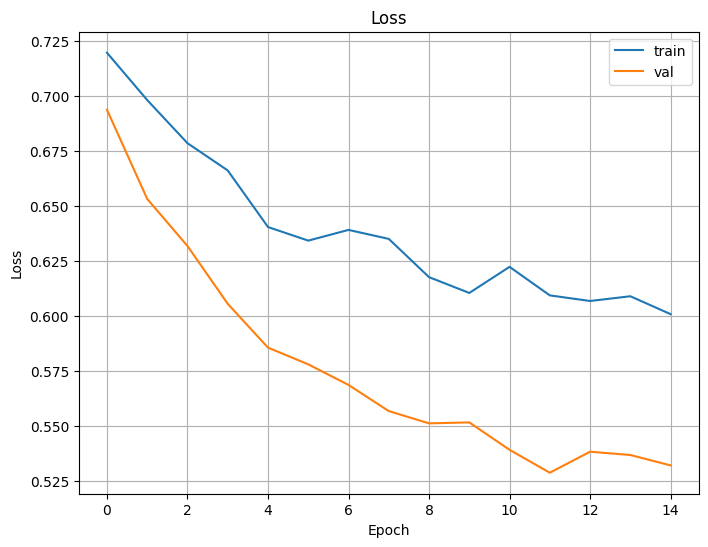

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, "loss.png"), dpi=300, bbox_inches="tight")
plt.show()

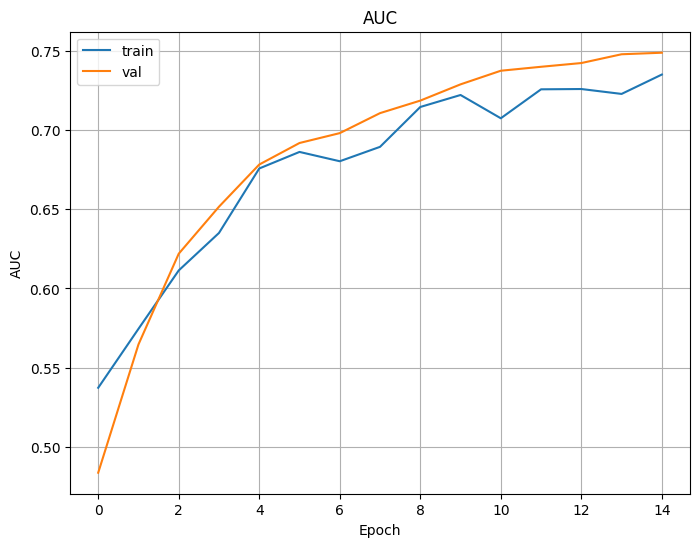

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(history.history["auc"], label="train")
plt.plot(history.history["val_auc"], label="val")
plt.title("AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, "auc.png"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
y_true = val_df["label"].values
y_pred_prob = model.predict(val_ds).ravel()

threshold = 0.5
y_pred = (y_pred_prob >= threshold).astype(int)

print("Min probability:", y_pred_prob.min())
print("Max probability:", y_pred_prob.max())
print("Mean probability:", y_pred_prob.mean())
print("Using threshold =", threshold)

10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step
Min probability: 0.043161795
Max probability: 0.76399165
Mean probability: 0.38786882
Using threshold = 0.5


In [ ]:
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

Confusion Matrix:
[[91 29]
 [14 16]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8667    0.7583    0.8089       120
           1     0.3556    0.5333    0.4267        30

    accuracy                         0.7133       150
   macro avg     0.6111    0.6458    0.6178       150
weighted avg     0.7644    0.7133    0.7324       150



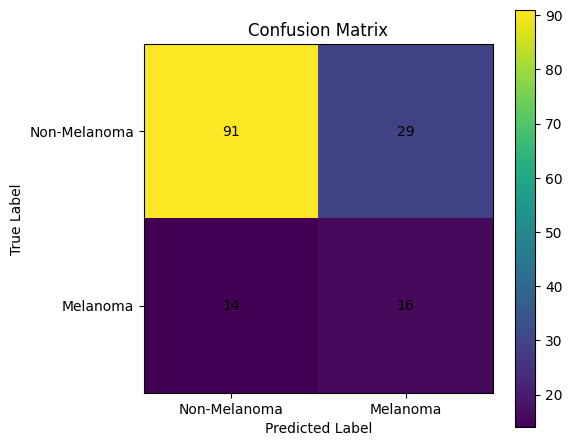

In [ ]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Non-Melanoma", "Melanoma"])
plt.yticks(tick_marks, ["Non-Melanoma", "Melanoma"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"), ha="center", va="center")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

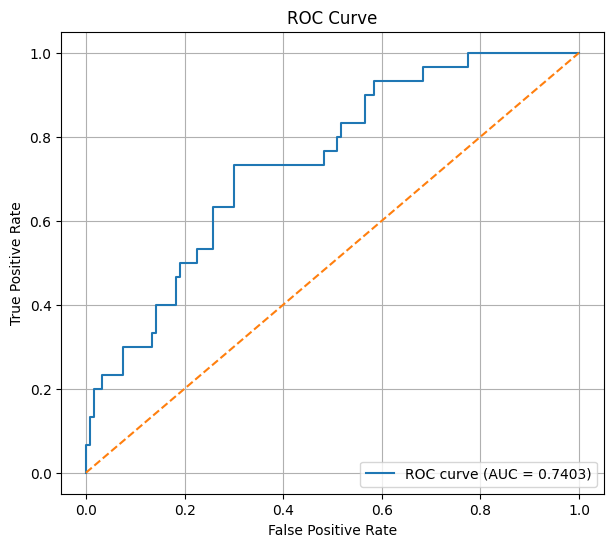

Validation ROC AUC: 0.7402777777777778


In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig(os.path.join(output_dir, "roc_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

print("Validation ROC AUC:", roc_auc)